# OTM-Only Basket -- Sandbox

**Motivation (Nitesh's email):** The basket should collectively achieve the LETF's delta
(2.0) via mathematically-derived contract counts, not guesswork. ATM and ITM calls carry
expensive intrinsic value that doesn't improve crash protection. OTM calls are cheaper
per contract; the basket spreads coverage across strike levels so different legs survive
different crash depths.

**Sizing:** 1/N dollar-delta split per leg. Each leg i: `n_i = (TSLL_LEVER * cum_tsll / N) / (delta_i * 100 * S)`.
Total basket delta at inception = TSLL_LEVER * cum_tsll = 2.0 (fully hedged, no over-hedging).

**CBA per leg:** cheapest of TSLA or TSLL call at each bucket.  
**Buckets:** 10%OTM / 20%OTM / 30%OTM. No ATM, no ITM.  
**Ranked by Max DD.**

| Label | Legs |
|---|---|
| Baseline | 10%OTM only (single-leg, reference) |
| A | 10%OTM + 20%OTM |
| B | 10%OTM + 20%OTM + 30%OTM |
| C | 20%OTM + 30%OTM (far OTM only) |
| D | 10%OTM + 30%OTM (skip 20%) |

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsla_underlying, load_tsll, load_tsla_calls, load_tsll_calls
from options_selection import select_contract, bs_delta, MONEYNESS_RANGES
from metrics import summarize
from cba_backtest import _position_cost

# Add 30% OTM bucket locally -- no production files touched
MONEYNESS_RANGES["30% OTM"] = (1.25, 1.35)

%matplotlib inline

tsll_df    = load_tsll()
r_tsll     = tsll_df.set_index("Date")["Close"].pct_change().dropna()
returns    = r_tsll.rename("TSLL").to_frame()

tsla_spot  = load_tsla_underlying().set_index("Date")["Close"].reindex(returns.index).ffill()
tsll_spot  = tsll_df.set_index("Date")["Close"].reindex(returns.index).ffill()

tsla_calls = load_tsla_calls()
tsll_calls = load_tsll_calls()

tsla_lut   = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()
tsll_lut   = tsll_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

tsla_sigma = (tsla_spot.pct_change().rolling(21).std() * 252**0.5).ffill().bfill()
tsll_sigma = (tsll_spot.pct_change().rolling(21).std() * 252**0.5).ffill().bfill()

n_years = len(returns) / 252

print(f"{len(returns):,} trading days  {returns.index.min().date()} -> {returns.index.max().date()}")
print(f"Simulation span: {n_years:.2f} years")
print(f"OTM buckets registered: {[k for k in MONEYNESS_RANGES if 'OTM' in k]}")
print("Data loaded.")

962 trading days  2022-08-10 -> 2026-06-10
Simulation span: 3.82 years
OTM buckets registered: ['10% OTM', '20% OTM', '30% OTM']
Data loaded.


In [2]:
TARGET_DTE = 90
MAX_DTE    = 110
ROLL_DTE   = 5
TSLL_LEVER = 2.0
R_RF       = 0.05

# Fallback chain: stay within OTM space; last resort is 10%OTM
FALLBACK = {
    "30% OTM": ["20% OTM", "10% OTM"],
    "20% OTM": ["10% OTM"],
    "10% OTM": ["20% OTM"],
}

COMPOSITIONS = {
    "Baseline (10%OTM only)": ["10% OTM"],
    "A: 10%OTM + 20%OTM":    ["10% OTM", "20% OTM"],
    "B: 10%OTM+20%OTM+30%OTM": ["10% OTM", "20% OTM", "30% OTM"],
    "C: 20%OTM + 30%OTM":    ["20% OTM", "30% OTM"],
    "D: 10%OTM + 30%OTM":    ["10% OTM", "30% OTM"],
}

print(f"target_dte={TARGET_DTE}  roll_dte={ROLL_DTE}  frictionless")
print(f"SIZING: 1/N dollar-delta per leg (total basket delta = LETF delta = 2.0 at inception)")
print(f"{len(COMPOSITIONS)} compositions -- OTM only, no ATM, no ITM")

target_dte=90  roll_dte=5  frictionless
SIZING: 1/N dollar-delta per leg (total basket delta = LETF delta = 2.0 at inception)
5 compositions -- OTM only, no ATM, no ITM


In [3]:
def _cba_leg(d, bucket, cum_val_per_leg):
    """
    For one basket leg: try both TSLA and TSLL (and fallback chain).
    cum_val_per_leg = cum_tsll / n_legs  (already divided -- 1/N share of total target).
    Return cheapest position dict, or None.
    """
    sig_a = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
    sig_b = float(tsll_sigma.loc[d]) if d in tsll_sigma.index else 0.5

    best_cost = float("inf")
    best_pos  = None

    for bucket_try in [bucket] + FALLBACK.get(bucket, []):
        row_a = select_contract(tsla_calls, tsla_spot, d, bucket_try, TARGET_DTE, max_dte=MAX_DTE)
        cost_a, n_a, entry_a = _position_cost(row_a, tsla_spot.loc[d], sig_a, TSLL_LEVER, cum_val_per_leg, d)
        if row_a is not None and cost_a < best_cost:
            best_cost = cost_a
            best_pos  = {"ul": "tsla", "raw_id": row_a["raw_id"],
                         "strike": float(row_a["strike"]), "expiry": row_a["expiry"],
                         "n": n_a, "price": entry_a}

        row_b = select_contract(tsll_calls, tsll_spot, d, bucket_try, TARGET_DTE, max_dte=MAX_DTE)
        cost_b, n_b, entry_b = _position_cost(row_b, tsll_spot.loc[d], sig_b, 1.0, cum_val_per_leg, d)
        if row_b is not None and cost_b < best_cost:
            best_cost = cost_b
            best_pos  = {"ul": "tsll", "raw_id": row_b["raw_id"],
                         "strike": float(row_b["strike"]), "expiry": row_b["expiry"],
                         "n": n_b, "price": entry_b}

        if best_pos is not None:
            break

    return best_pos


def simulate_otm_basket(returns, basket_buckets):
    """
    Short $1 TSLL + OTM-only call basket.
    Each leg gets 1/N of the total LETF dollar-delta target (mathematically correct sizing).
    CBA per leg: cheapest of TSLA or TSLL at the target OTM bucket.
    Roll when earliest-expiring leg hits ROLL_DTE.

    Returns: (equity, n_misses, tsll_fills, tsla_fills, n_fallbacks)
    """
    n_legs      = len(basket_buckets)
    cum_tsll    = (1 + returns["TSLL"]).cumprod()
    base_equity = 2.0 - cum_tsll

    equity      = pd.Series(index=returns.index, dtype=float)
    positions   = {b: None for b in basket_buckets}
    option_pnl  = 0.0
    n_misses    = 0
    n_fallbacks = 0
    tsll_fills  = 0
    tsla_fills  = 0

    def mtm(pos, d):
        lut  = tsla_lut if pos["ul"] == "tsla" else tsll_lut
        spot = tsla_spot if pos["ul"] == "tsla" else tsll_spot
        if d > pos["expiry"]:
            return max(float(spot.loc[d]) - pos["strike"], 0.0)
        px = lut.get((pos["raw_id"], d))
        return float(px) if (px is not None and not pd.isna(px)) else pos["price"]

    for d in returns.index:
        held_dtes = [(positions[b]["expiry"] - d).days
                     if positions[b] is not None else -1
                     for b in basket_buckets]
        need_roll = any(positions[b] is None for b in basket_buckets) \
                    or min(held_dtes) < ROLL_DTE

        if need_roll:
            for b in basket_buckets:
                if positions[b] is not None:
                    option_pnl += positions[b]["n"] * 100 * (
                        mtm(positions[b], d) - positions[b]["price"])

            # 1/N split: each leg gets its proportional share of total LETF dollar-delta
            cum_val_per_leg = float(cum_tsll.loc[d]) / n_legs
            new_positions = {}
            for b in basket_buckets:
                pos = _cba_leg(d, b, cum_val_per_leg)
                if pos is None:
                    n_misses += 1
                else:
                    if pos["ul"] == "tsll": tsll_fills += 1
                    else:                   tsla_fills += 1
                new_positions[b] = pos
            positions = new_positions

        else:
            for b in basket_buckets:
                if positions[b] is not None:
                    px = mtm(positions[b], d)
                    option_pnl            += positions[b]["n"] * 100 * (px - positions[b]["price"])
                    positions[b]["price"]  = px

        equity.loc[d] = base_equity.loc[d] + option_pnl

    return equity, n_misses, tsll_fills, tsla_fills

In [4]:
rows   = []
curves = {}

for label, buckets in COMPOSITIONS.items():
    eq, n_miss, tsll_f, tsla_f = simulate_otm_basket(returns, buckets)
    eq = eq / eq.iloc[0]
    assert eq.isna().sum() == 0, f"{label}: NaNs in equity"
    curves[label] = eq

    row = summarize(eq, eq.pct_change().dropna(), label)
    total_f = tsll_f + tsla_f
    row["TSLL%"]      = f"{tsll_f/total_f*100:.0f}%" if total_f else "0%"
    row["Leg misses"] = n_miss
    rows.append(row)
    print(f"{label:40s}  CAGR={row['CAGR']:+.1%}  Sharpe={row['Sharpe']:.2f}  "
          f"MaxDD={row['Max DD']:.1%}  TSLL={row['TSLL%']}")

results_df = pd.DataFrame(rows).sort_values("Max DD", ascending=False)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", None)

print()
print("=== OTM-ONLY BASKET (CBA) -- Ranked by Max DD (best first) ===")
print(results_df[["Strategy", "CAGR", "Ann. Vol", "Sharpe", "Max DD",
                  "Calmar", "TSLL%", "Leg misses"]].to_string(index=False))

print()
print("--- Reference: prior best results ---")
print("Production Pareto-optimal (10%OTM/90d/roll@5d):  CAGR=+28.5%  Sharpe=1.02  MaxDD=-20.5%")
print("1/N CBA best (C: 10%ITM+ATM+10%OTM+20%OTM):      CAGR=+13.5%  Sharpe=0.57  MaxDD=-26.4%")

Baseline (10%OTM only)                    CAGR=+10.0%  Sharpe=0.45  MaxDD=-33.2%  TSLL=68%
A: 10%OTM + 20%OTM                        CAGR=+13.9%  Sharpe=0.52  MaxDD=-47.2%  TSLL=57%


B: 10%OTM+20%OTM+30%OTM                   CAGR=+9.0%  Sharpe=0.41  MaxDD=-58.3%  TSLL=54%
C: 20%OTM + 30%OTM                        CAGR=+10.0%  Sharpe=0.44  MaxDD=-65.0%  TSLL=50%


D: 10%OTM + 30%OTM                        CAGR=+7.6%  Sharpe=0.39  MaxDD=-61.5%  TSLL=53%

=== OTM-ONLY BASKET (CBA) -- Ranked by Max DD (best first) ===
               Strategy     CAGR  Ann. Vol   Sharpe    Max DD   Calmar TSLL%  Leg misses
 Baseline (10%OTM only) 0.099934  0.328847 0.453037 -0.331802 0.301185   68%           0
     A: 10%OTM + 20%OTM 0.139334  0.393500 0.524068 -0.471798 0.295325   57%           0
B: 10%OTM+20%OTM+30%OTM 0.089590  0.486343 0.412309 -0.582922 0.153690   54%           0
     D: 10%OTM + 30%OTM 0.076112  0.523775 0.392704 -0.615003 0.123758   53%           0
     C: 20%OTM + 30%OTM 0.099642  0.561128 0.440941 -0.650274 0.153231   50%           0

--- Reference: prior best results ---
Production Pareto-optimal (10%OTM/90d/roll@5d):  CAGR=+28.5%  Sharpe=1.02  MaxDD=-20.5%
1/N CBA best (C: 10%ITM+ATM+10%OTM+20%OTM):      CAGR=+13.5%  Sharpe=0.57  MaxDD=-26.4%


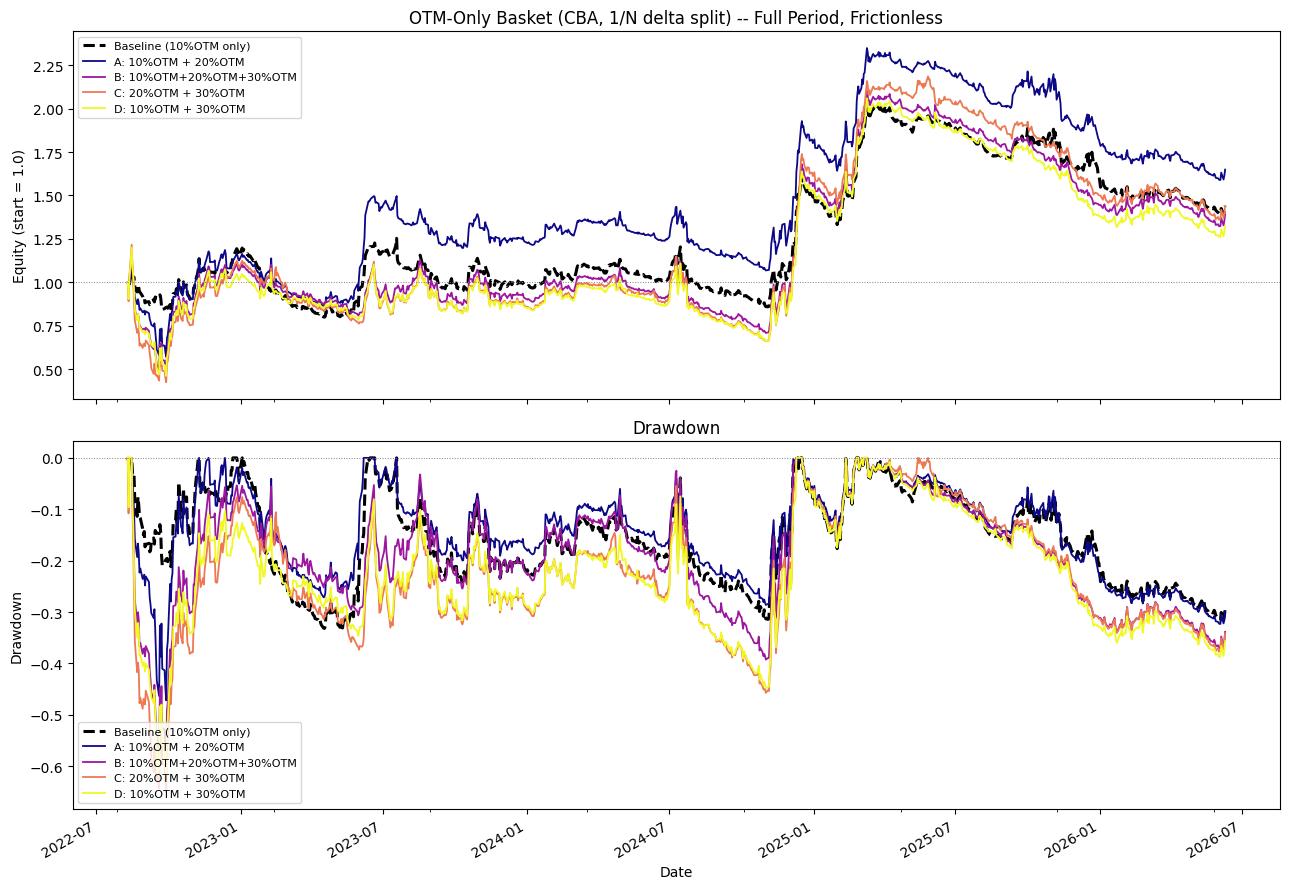

Saved: observations/strategies/sandbox/otm_basket.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

non_bl = [l for l in curves if "Baseline" not in l]
colors = cm.plasma([i / max(len(non_bl)-1, 1) for i in range(len(non_bl))])

bl = "Baseline (10%OTM only)"
curves[bl].plot(ax=axes[0], label=bl, color="black", linewidth=2.2, linestyle="--")
(curves[bl] / curves[bl].cummax() - 1).plot(ax=axes[1], label=bl, color="black",
                                              linewidth=2.2, linestyle="--")
for label, color in zip(non_bl, colors):
    curves[label].plot(ax=axes[0], label=label, color=color, linewidth=1.3)
    (curves[label] / curves[label].cummax() - 1).plot(ax=axes[1], label=label,
                                                       color=color, linewidth=1.3)

axes[0].axhline(1.0, color="grey", linestyle=":", linewidth=0.7)
axes[0].set_title("OTM-Only Basket (CBA, 1/N delta split) -- Full Period, Frictionless")
axes[0].set_ylabel("Equity (start = 1.0)")
axes[0].legend(fontsize=8, loc="upper left")

axes[1].axhline(0.0, color="grey", linestyle=":", linewidth=0.7)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].legend(fontsize=8, loc="lower left")

fig.tight_layout()
out = ROOT / "observations" / "strategies" / "sandbox" / "otm_basket.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out.relative_to(ROOT)}")